# Customer Segmentation Benchmark: K-Means vs. Fuzzy C-Means vs. HDBSCAN
An end-to-end machine learning pipeline for RFM customer segmentation on the UCI Online Retail dataset. This notebook processes raw transactional data, engineers net RFM features, transforms skewed distributions, optimizes hyperparameters using Optuna (TPE), and benchmarks three distinct clustering paradigms.

In [1]:
# ================================================================
# CELL 1 — SETUP + DATA
# ================================================================
%pip install -q optuna scikit-fuzzy ucimlrepo openpyxl

from ucimlrepo import fetch_ucirepo
import pandas as pd, numpy as np

retail = fetch_ucirepo(id=352)     # Online Retail. (Online Retail II would be id=502)
df = retail.data.original          # full raw table: InvoiceNo, StockCode, Description,
                                   # Quantity, InvoiceDate, UnitPrice, CustomerID, Country
print(df.shape)
df.head()

Note: you may need to restart the kernel to use updated packages.
(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 1. Data Preprocessing & Cleaning
We clean non-customer transactions, split positive purchases from cancellations, calculate line totals, and build an audit report of dropped rows.

In [2]:
def run_pipeline(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    df = df.copy()
    rep = {}

    # Standardize data types
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
    df["InvoiceNo"] = df["InvoiceNo"].astype(str).str.strip()
    df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
    df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")
    df["CustomerID"] = pd.to_numeric(df["CustomerID"], errors="coerce").astype("Int64")
    rep["raw_rows"] = len(df)

    # Remove exact duplicates
    n0 = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    rep["duplicates_dropped"] = n0 - len(df)

    # Track missing customer identifiers
    df["HasCustomerID"] = df["CustomerID"].notna()
    rep["missing_customerid"] = int((~df["HasCustomerID"]).sum())

    # Split transactions: Returns vs. Purchases
    is_cancel = df["Quantity"] < 0
    cancels, sales = df[is_cancel].copy(), df[~is_cancel].copy()
    rep["cancels_rows"] = len(cancels)

    # Filter bad prices / freebies
    bad = sales["UnitPrice"] <= 0
    rep["anomalous_price_rows"] = int(bad.sum())
    sales = sales[~bad].copy()

    # Calculate financial values
    sales["TotalRevenue"] = sales["Quantity"] * sales["UnitPrice"]
    cancels["RevenueLost"] = (cancels["Quantity"] * cancels["UnitPrice"]).abs()
    cancels = cancels[cancels["RevenueLost"] > 0].copy()
    rep["sales_rows"] = len(sales)

    # Display audit report
    for k, v in rep.items():
        print(f"{k:<22}: {v:>9,}")

    return sales, cancels, rep

sales, cancels, report = run_pipeline(df)

raw_rows              :   541,909
duplicates_dropped    :     5,268
missing_customerid    :   135,037
cancels_rows          :    10,587
anomalous_price_rows  :     1,176
sales_rows            :   524,878


## 2. RFM Feature Engineering (Net Values)
We aggregate transaction metrics per customer. Returns are subtracted directly from gross purchases to compute **Net Monetary Value**. Unidentified guests are excluded from clustering.

In [3]:
def build_rfm(sales: pd.DataFrame, cancels: pd.DataFrame, 
              snapshot: pd.Timestamp | None = None) -> pd.DataFrame:
    cust_sales = sales[sales["HasCustomerID"]]
    cust_cancels = cancels[cancels["HasCustomerID"]]
    snapshot = snapshot or (sales["InvoiceDate"].max() + pd.Timedelta(days=1))

    pos = cust_sales.groupby("CustomerID").agg(
        last_purchase=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique"),
        GrossMonetary=("TotalRevenue", "sum")
    )
    ret = cust_cancels.groupby("CustomerID").agg(
        ReturnsMonetary=("RevenueLost", "sum"),
        ReturnEvents=("InvoiceNo", "nunique")
    )

    rfm = pos.join(ret, how="outer")
    returns_only = rfm["Frequency"].isna()
    rfm = rfm.dropna(subset=["Frequency", "last_purchase"]).copy()
    rfm = rfm.fillna({"ReturnsMonetary": 0.0, "ReturnEvents": 0})

    rfm["Recency"] = (snapshot - rfm["last_purchase"]).dt.days
    rfm["Monetary"] = rfm["GrossMonetary"] - rfm["ReturnsMonetary"]
    rfm["HadFullReturn"] = rfm["Monetary"] <= 0
    rfm = rfm.drop(columns="last_purchase")
    rfm.index = rfm.index.astype(int)

    print(f"Active RFM Customers: {len(rfm):,} | Dropped Returns-Only: {int(returns_only.sum()):,}")
    return rfm

rfm = build_rfm(sales, cancels)
rfm.head()

Active RFM Customers: 4,338 | Dropped Returns-Only: 33


,Frequency,GrossMonetary,ReturnsMonetary,ReturnEvents,Recency,Monetary,HadFullReturn
CustomerID,,,,,,,
12346,1.0,77183.60,77183.6,1.0,326,0.00,True
12347,7.0,4310.00,0.0,0.0,2,4310.00,False
12348,4.0,1797.24,0.0,0.0,75,1797.24,False
12349,1.0,1757.55,0.0,0.0,19,1757.55,False
12350,1.0,334.40,0.0,0.0,310,334.40,False


## 3. Power Transformations & Feature Normalization
RFM metrics typically exhibit extreme positive skewness. We utilize **Yeo-Johnson** transformations to pull long tails into Gaussian distributions while handling zero or negative net monetary balances natively.

In [4]:
from sklearn.preprocessing import PowerTransformer, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline

FEATURES = ["Recency", "Frequency", "Monetary"]

def clip_log1p(X):
    return np.log1p(np.clip(X, 0, None))

def make_transformer(method: str = "yeo-johnson"):
    if method == "yeo-johnson":
        return PowerTransformer(method="yeo-johnson", standardize=True)
    elif method == "log1p":
        return Pipeline([
            ("log", FunctionTransformer(clip_log1p)),
            ("scale", StandardScaler())
        ])
    raise ValueError(f"Unknown method: {method}")

# Compare transformation effects on skewness
skew_df = pd.DataFrame({
    "Raw": rfm[FEATURES].skew(),
    "Log1p": pd.DataFrame(make_transformer("log1p").fit_transform(rfm[FEATURES]), columns=FEATURES).skew(),
    "Yeo-Johnson": pd.DataFrame(make_transformer("yeo-johnson").fit_transform(rfm[FEATURES]), columns=FEATURES).skew()
}).round(3)

print("Skewness Comparison (Target: near 0.0):")
print(skew_df)

METHOD = "yeo-johnson"
transformer = make_transformer(METHOD)
Xt = transformer.fit_transform(rfm[FEATURES].to_numpy())

Skewness Comparison (Target: near 0.0):
              Raw  Log1p  Yeo-Johnson
Recency     1.246 -0.379       -0.057
Frequency  12.067  1.209        0.217
Monetary   21.635 -0.208        3.698


## 4. Hyperparameter Tuning via Optuna
We set up individual TPE (Tree-structured Parzen Estimator) trials for **K-Means**, **Fuzzy C-Means (FCM)**, and **HDBSCAN**. Performance is scored on Silhouette coefficient and penalized for unclustered/noise observations.

In [5]:
import optuna
import skfuzzy as fuzz
from sklearn.cluster import KMeans, HDBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

RNG = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)

def safe_scores(Xt, labels) -> dict | None:
    mask = labels >= 0
    uniq = np.unique(labels[mask])
    if uniq.size < 2 or mask.sum() < 3:
        return None
    counts = pd.Series(labels[mask]).value_counts()
    return {
        "silhouette": silhouette_score(Xt[mask], labels[mask]),
        "calinski_harabasz": calinski_harabasz_score(Xt[mask], labels[mask]),
        "davies_bouldin": davies_bouldin_score(Xt[mask], labels[mask]),
        "n_clusters": int(uniq.size),
        "noise_%": round(100 * (~mask).mean(), 1),
        "min_cluster_%": round(100 * counts.min() / counts.sum(), 1)
    }

def objective_score(s: dict) -> float:
    return s["silhouette"] * (1.0 - s["noise_%"] / 100.0)

def objective_kmeans(trial, Xt):
    k = trial.suggest_int("k", 3, 10)
    init = trial.suggest_categorical("init", ["k-means++", "random"])
    labels = KMeans(n_clusters=k, init=init, n_init=3, random_state=RNG).fit_predict(Xt)
    s = safe_scores(Xt, labels)
    if s is None: raise optuna.TrialPruned()
    return objective_score(s)

def objective_fcm(trial, Xt):
    c = trial.suggest_int("c", 3, 10)
    m = trial.suggest_float("m", 1.2, 3.0)
    # Explicit deterministic seed per trial
    seed = RNG + trial.number
    u = fuzz.cluster.cmeans(Xt.T, c=c, m=m, error=0.01, maxiter=200, seed=seed)[1]
    s = safe_scores(Xt, u.argmax(axis=0))
    if s is None: raise optuna.TrialPruned()
    return objective_score(s)

def objective_hdbscan(trial, Xt):
    params = dict(
        min_cluster_size=trial.suggest_int("min_cluster_size", 10, 100),
        min_samples=trial.suggest_int("min_samples", 3, 50),
        cluster_selection_epsilon=trial.suggest_float("cluster_selection_epsilon", 0.0, 0.5),
        cluster_selection_method=trial.suggest_categorical("cluster_selection_method", ["eom", "leaf"])
    )
    labels = HDBSCAN(**params).fit_predict(Xt)
    s = safe_scores(Xt, labels)
    if s is None: raise optuna.TrialPruned()
    return objective_score(s)

def tune_models(Xt, n_trials=50) -> dict:
    studies = {}
    objectives = [("K-Means", objective_kmeans), ("Fuzzy C-Means", objective_fcm), ("HDBSCAN", objective_hdbscan)]
    for name, obj in objectives:
        study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RNG))
        study.optimize(lambda t, o=obj: o(t, Xt), n_trials=n_trials, show_progress_bar=False)
        print(f"{name:<14} | Best Score: {study.best_value:.4f} | Best Params: {study.best_params}")
        studies[name] = study
    return studies

studies = tune_models(Xt, n_trials=30)

K-Means        | Best Score: 0.4433 | Best Params: {'k': 3, 'init': 'k-means++'}
Fuzzy C-Means  | Best Score: 0.4038 | Best Params: {'c': 8, 'm': 1.204828988042268}


/home/shawky/Documents/nti/actual nti/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/home/shawky/Documents/nti/actual nti/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/home/shawky/Documents/nti/actual nti/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/home/shawky/Documents/nti/actual nti/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly 

HDBSCAN        | Best Score: 0.2645 | Best Params: {'min_cluster_size': 98, 'min_samples': 50, 'cluster_selection_epsilon': 0.20392941597747727, 'cluster_selection_method': 'eom'}


## 5. Execution & Leaderboard
We fit all three models using their optimal hyperparameters, generate cluster metrics, and map segment identities back to the main RFM dataset.

In [6]:
# Refit models using optimal hyper-parameters
p_km = studies["K-Means"].best_params
km = KMeans(n_clusters=p_km["k"], init=p_km["init"], n_init=10, random_state=RNG).fit(Xt)

p_fcm = studies["Fuzzy C-Means"].best_params
cntr, u = fuzz.cluster.cmeans(Xt.T, c=p_fcm["c"], m=p_fcm["m"], error=0.01, maxiter=200, seed=RNG)[:2]

p_hdb = studies["HDBSCAN"].best_params
hdb = HDBSCAN(**p_hdb).fit(Xt)

models = {
    "K-Means": {"labels": km.labels_},
    "Fuzzy C-Means": {"labels": u.argmax(axis=0), "confidence": u.max(axis=0)},
    "HDBSCAN": {"labels": hdb.labels_}
}

# Construct Leaderboard Table
lb = pd.DataFrame({name: safe_scores(Xt, m["labels"]) for name, m in models.items()}).T
lb["score"] = lb["silhouette"] * (1.0 - lb["noise_%"] / 100.0)
lb = lb.sort_values("score", ascending=False).round(3)
winner = lb.index[0]

print("=== LEADERBOARD ===")
print(lb)
print(f"\nModel Winner: {winner}")

# Re-label clusters hierarchically by mean net spend
def relabel_by_monetary(labels, monetary):
    order = (pd.DataFrame({"c": labels, "m": monetary})
             .query("c >= 0").groupby("c")["m"].mean()
             .sort_values(ascending=False).index.tolist())
    remap = {old: f"Segment_{chr(65+i)}" for i, old in enumerate(order)}
    return np.array([remap.get(int(l), "Noise") for l in labels])

rfm_out = rfm.copy()
rfm_out["Winning_Segment"] = relabel_by_monetary(models[winner]["labels"], rfm["Monetary"])
rfm_out["FCM_Confidence"] = models["Fuzzy C-Means"]["confidence"].round(3)

profile = rfm_out.groupby("Winning_Segment")[FEATURES].mean().round(1)
profile["Customer_Count"] = rfm_out["Winning_Segment"].value_counts()
profile["Revenue_Share_%"] = (100 * rfm_out.groupby("Winning_Segment")["Monetary"].sum() / rfm_out["Monetary"].sum()).round(1)
print(f"\nWinner Profile Summary ({winner}):")
print(profile.sort_values("Monetary", ascending=False))

/home/shawky/Documents/nti/actual nti/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


=== LEADERBOARD ===
               silhouette  calinski_harabasz  davies_bouldin  n_clusters  \
K-Means             0.443           2555.856           0.775         3.0   
Fuzzy C-Means       0.404           2434.970           0.797         8.0   
HDBSCAN             0.283           2679.081           1.351         3.0   

               noise_%  min_cluster_%  score  
K-Means            0.0            0.8  0.443  
Fuzzy C-Means      0.0            0.1  0.404  
HDBSCAN            6.4           20.0  0.264  

Model Winner: K-Means

Winner Profile Summary (K-Means):
                 Recency  Frequency  Monetary  Customer_Count  Revenue_Share_%
Winning_Segment                                                               
Segment_A            7.4       52.2   67256.7              34             27.6
Segment_B           28.2        6.5    2389.7            2063             59.5
Segment_C          153.1        1.5     478.5            2241             12.9


In [7]:
# Refit models using optimal hyper-parameters
p_km = studies["K-Means"].best_params
km = KMeans(n_clusters=p_km["k"], init=p_km["init"], n_init=10, random_state=RNG).fit(Xt)

p_fcm = studies["Fuzzy C-Means"].best_params
cntr, u = fuzz.cluster.cmeans(Xt.T, c=p_fcm["c"], m=p_fcm["m"], error=0.01, maxiter=200, seed=RNG)[:2]

p_hdb = studies["HDBSCAN"].best_params
hdb = HDBSCAN(**p_hdb).fit(Xt)

models = {
    "K-Means": {"labels": km.labels_},
    "Fuzzy C-Means": {"labels": u.argmax(axis=0), "confidence": u.max(axis=0)},
    "HDBSCAN": {"labels": hdb.labels_}
}

# Construct Leaderboard Table
lb = pd.DataFrame({name: safe_scores(Xt, m["labels"]) for name, m in models.items()}).T
lb["score"] = lb["silhouette"] * (1.0 - lb["noise_%"] / 100.0)
lb = lb.sort_values("score", ascending=False).round(3)
winner = lb.index[0]

print("=== LEADERBOARD ===")
print(lb)
print(f"\nModel Winner: {winner}")

# Re-label clusters hierarchically by mean net spend
def relabel_by_monetary(labels, monetary):
    order = (pd.DataFrame({"c": labels, "m": monetary})
             .query("c >= 0").groupby("c")["m"].mean()
             .sort_values(ascending=False).index.tolist())
    remap = {old: f"Segment_{chr(65+i)}" for i, old in enumerate(order)}
    return np.array([remap.get(int(l), "Noise") for l in labels])

rfm_out = rfm.copy()
rfm_out["Winning_Segment"] = relabel_by_monetary(models[winner]["labels"], rfm["Monetary"])
rfm_out["FCM_Confidence"] = models["Fuzzy C-Means"]["confidence"].round(3)

profile = rfm_out.groupby("Winning_Segment")[FEATURES].mean().round(1)
profile["Customer_Count"] = rfm_out["Winning_Segment"].value_counts()
profile["Revenue_Share_%"] = (100 * rfm_out.groupby("Winning_Segment")["Monetary"].sum() / rfm_out["Monetary"].sum()).round(1)
print(f"\nWinner Profile Summary ({winner}):")
print(profile.sort_values("Monetary", ascending=False))

/home/shawky/Documents/nti/actual nti/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


=== LEADERBOARD ===
               silhouette  calinski_harabasz  davies_bouldin  n_clusters  \
K-Means             0.443           2555.856           0.775         3.0   
Fuzzy C-Means       0.404           2434.970           0.797         8.0   
HDBSCAN             0.283           2679.081           1.351         3.0   

               noise_%  min_cluster_%  score  
K-Means            0.0            0.8  0.443  
Fuzzy C-Means      0.0            0.1  0.404  
HDBSCAN            6.4           20.0  0.264  

Model Winner: K-Means

Winner Profile Summary (K-Means):
                 Recency  Frequency  Monetary  Customer_Count  Revenue_Share_%
Winning_Segment                                                               
Segment_A            7.4       52.2   67256.7              34             27.6
Segment_B           28.2        6.5    2389.7            2063             59.5
Segment_C          153.1        1.5     478.5            2241             12.9


## 6. Visual Analytics & Boundary Inspection
We project the scaled feature space down to 2 principal components (PCA) to visually inspect decision boundaries, overlay assignment confidence for Fuzzy C-Means, and compare final leaderboard scores.

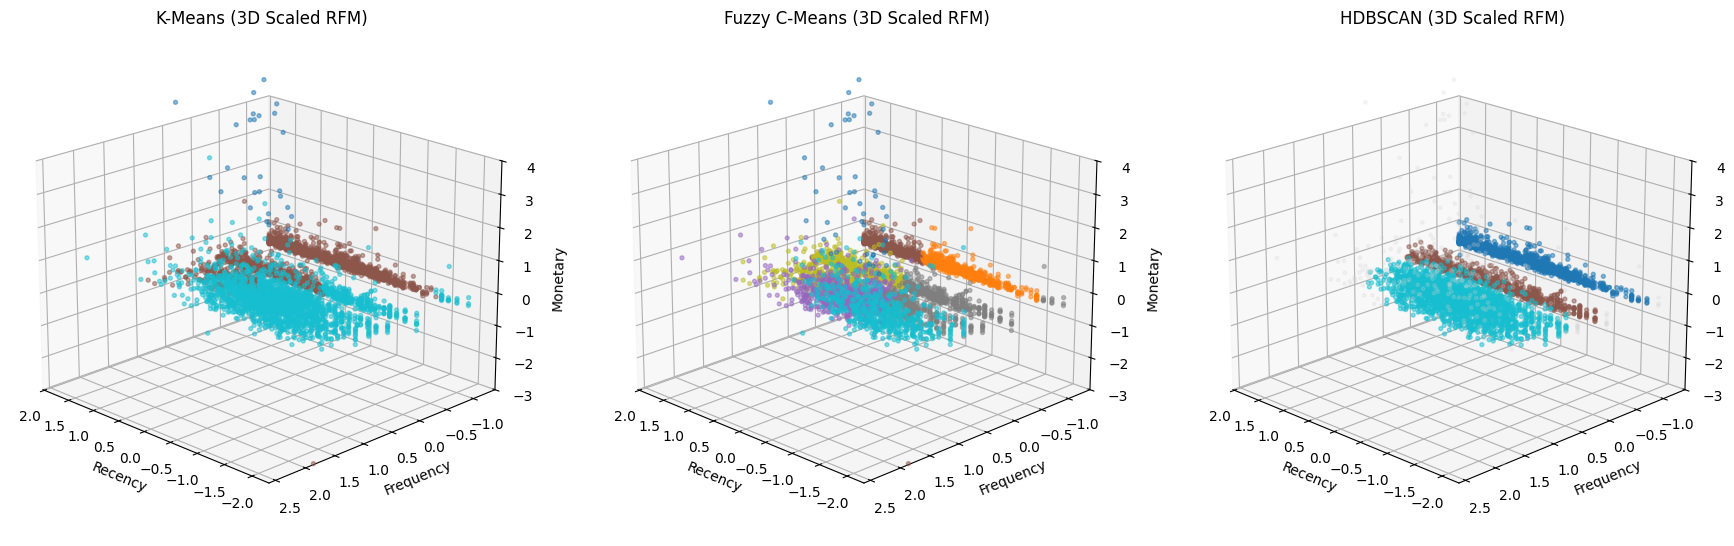

In [17]:
# ================================================================
# CELL 7 — MATPLOTLIB 3D VISUALIZATION (OPTIMIZED SCALES)
# ================================================================
import matplotlib.pyplot as plt

# Optional: Uncomment the next line if 'ipympl' is installed for interactive drag-and-rotate
# %matplotlib widget

fig = plt.figure(figsize=(18, 5.5))

for idx, (name, m_data) in enumerate(models.items(), start=1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')
    labels = m_data["labels"]
    noise = labels < 0
    
    # Plot valid cluster points
    ax.scatter(
        Xt[~noise, 0], Xt[~noise, 1], Xt[~noise, 2],
        c=labels[~noise], cmap="tab10", s=8, alpha=0.5
    )
    
    # Highlight noise points (for HDBSCAN)
    if noise.any():
        ax.scatter(
            Xt[noise, 0], Xt[noise, 1], Xt[noise, 2],
            c="lightgray", s=6, alpha=0.2, label="Noise"
        )
    
    ax.set_title(f"{name} (3D Scaled RFM)")
    ax.set_xlabel("Recency")
    ax.set_ylabel("Frequency")
    ax.set_zlabel("Monetary")
    
    # Clip Z-axis to remove outlier distortion and focus on cluster distribution
    ax.set_zlim(-3, 4)
    
    # Adjust initial viewing angle (elev=elevation angle, azim=azimuthal angle)
    ax.view_init(elev=20, azim=135)

plt.tight_layout()
plt.show()